# 🌊 Inondations — Entraînement des modèles ML
**PFE 2026 — Suivi des Catastrophes Naturelles au Maroc**
- **Target :** `flood_risk` (low / medium / high)
- **Dataset :** `data_inondations.csv` — 5 909 lignes
- **Modèles :** Régression Logistique, Arbre de Décision, Random Forest

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from imblearn.over_sampling import SMOTE

## 1. Chargement des données

(5909, 11)
PRECTOTCORR    0
T2M            0
RH2M           0
WS2M           0
region         0
latitude       0
longitude      0
year           0
month          0
season         0
flood_risk     0
dtype: int64


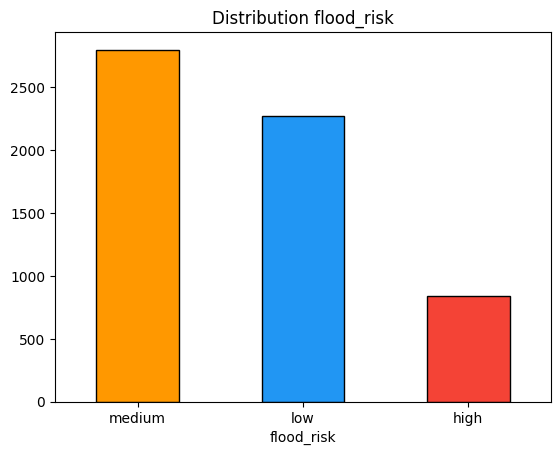

In [31]:
df = pd.read_csv('../data/data_inondations.csv')
print(df.shape)
print(df.isnull().sum())
df['flood_risk'].value_counts().plot(
    kind='bar', color=['#FF9800','#2196F3','#F44336'], edgecolor='black'
)
plt.title('Distribution flood_risk')
plt.xticks(rotation=0)
plt.show()

## 2. Preprocessing

In [25]:
le_region = LabelEncoder()
le_season  = LabelEncoder()
df['region'] = le_region.fit_transform(df['region'])
df['season']  = le_season.fit_transform(df['season'])

X = df[['PRECTOTCORR', 'T2M', 'RH2M', 'WS2M', 'latitude', 'longitude', 'season', 'region', 'year', 'month']]

le_target = LabelEncoder()
y = le_target.fit_transform(df['flood_risk'])

print("Classes :", list(le_target.classes_))
print("Shape X :", X.shape)

Classes : ['high', 'low', 'medium']
Shape X : (5909, 10)


## 3. Split Train/Test + SMOTE

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Après SMOTE :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test set    :", X_test.shape[0], "lignes (non touché)")

Après SMOTE : {np.int64(0): np.int64(2238), np.int64(1): np.int64(2238), np.int64(2): np.int64(2238)}
Test set    : 1182 lignes (non touché)


## 4. Entraînement des 3 modèles

In [27]:
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Arbre de Décision'    : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model' : model,
        'y_pred': y_pred,
        'acc'   : accuracy_score(y_test, y_pred),
        'f1'    : f1_score(y_test, y_pred, average='weighted'),
    }
    print(f"{name} → Acc: {results[name]['acc']:.4f} | F1: {results[name]['f1']:.4f}")

Régression Logistique → Acc: 0.5364 | F1: 0.5294
Arbre de Décision → Acc: 0.5262 | F1: 0.5305
Random Forest → Acc: 0.5956 | F1: 0.5956


## 5. Métriques détaillées

In [28]:
class_names = list(le_target.classes_)

for name, res in results.items():
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_test, res['y_pred'], target_names=class_names))


  Régression Logistique
              precision    recall  f1-score   support

        high       0.33      0.61      0.43       168
         low       0.61      0.73      0.66       454
      medium       0.61      0.36      0.45       560

    accuracy                           0.54      1182
   macro avg       0.52      0.57      0.51      1182
weighted avg       0.57      0.54      0.53      1182


  Arbre de Décision
              precision    recall  f1-score   support

        high       0.33      0.45      0.38       168
         low       0.58      0.57      0.58       454
      medium       0.57      0.51      0.54       560

    accuracy                           0.53      1182
   macro avg       0.49      0.51      0.50      1182
weighted avg       0.54      0.53      0.53      1182


  Random Forest
              precision    recall  f1-score   support

        high       0.42      0.45      0.44       168
         low       0.63      0.68      0.65       454
      medium

## 6. Matrices de confusion

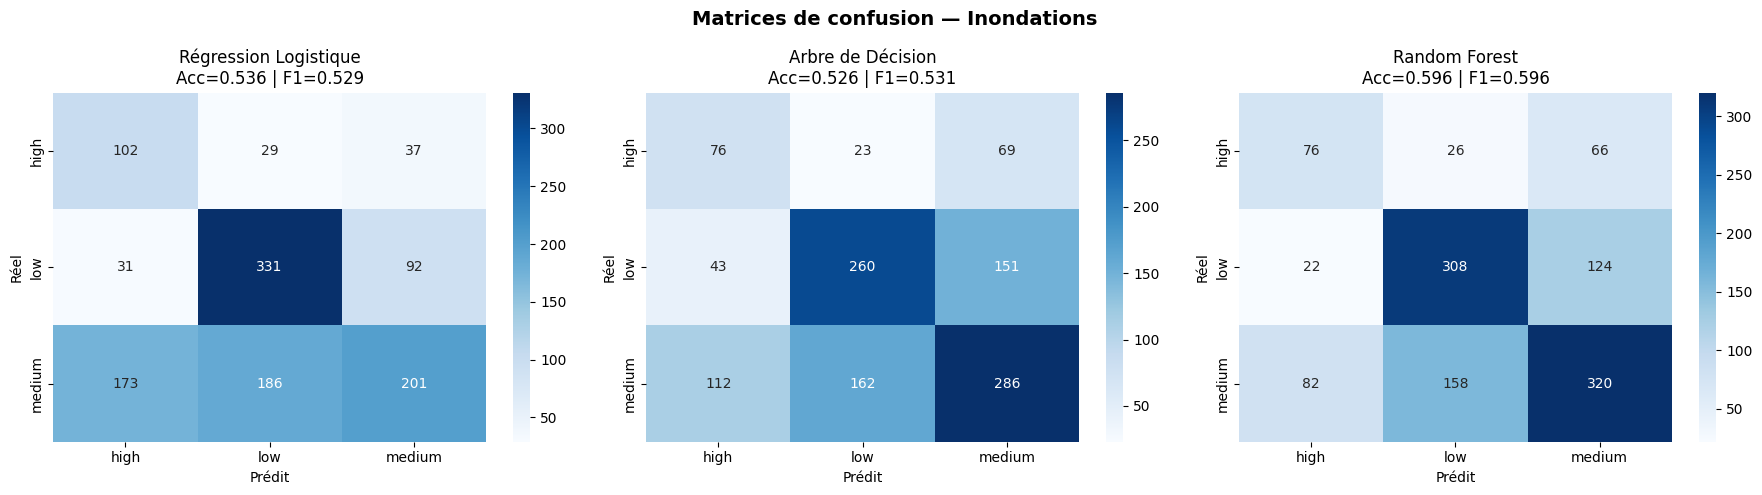

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name}\nAcc={res['acc']:.3f} | F1={res['f1']:.3f}")
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — Inondations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Comparaison des modèles

                       Accuracy  F1-score
Modèle                                   
Régression Logistique    0.5364    0.5294
Arbre de Décision        0.5262    0.5305
Random Forest            0.5956    0.5956


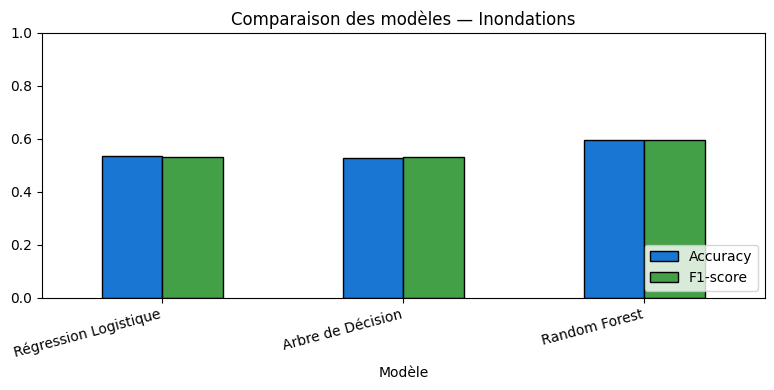

In [35]:
summary = pd.DataFrame({
    'Modèle'  : list(results.keys()),
    'Accuracy': [r['acc'] for r in results.values()],
    'F1-score': [r['f1']  for r in results.values()],
}).set_index('Modèle')

print(summary.round(4))

summary.plot(kind='bar', figsize=(8, 4), color=['#1976D2', '#43A047'],
             edgecolor='black', ylim=(0, 1))
plt.title('Comparaison des modèles — Inondations')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

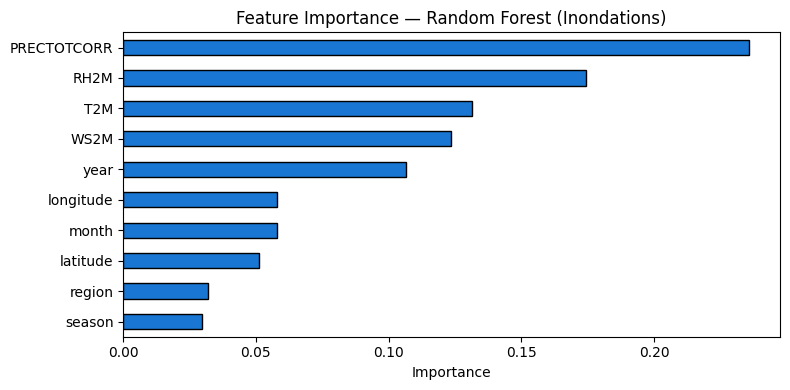

In [36]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 4), color='#1976D2', edgecolor='black')
plt.title('Feature Importance — Random Forest (Inondations)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Export du modèle choisi (.pkl) (Aprés la décision final)

In [ ]:
# ⚠️ Ne pas exécuter avant la décision de la coordinatrice
BEST = 'Random Forest'  # <-- modifier selon la décision

os.makedirs('../models', exist_ok=True)

with open('../models/inondation_model.pkl', 'wb') as f:
    pickle.dump(results[BEST]['model'], f)

with open('../models/inondation_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/inondation_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

print("✅ Modèle exporté dans models/")

## 9. Résumé — À envoyer à la coordinatrice

| Modèle | Accuracy | F1-score |
|--------|----------|----------|
| Régression Logistique | | |
| Arbre de Décision | | |
| Random Forest | | |

**Modèle retenu :** _______________